In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

# from utility.sv_fig import savefig
from utility.make_cm import make_confusion_matrix
from utility.get_g_result import get_gamma_results
from utility.plt_result import plot_results

In [3]:
# updated savefig due to bounding box issues
def savefig(filename, crop=False,dpi=600,quality=95):
    fig = plt.gcf()

    import matplotlib as mpl
    from PIL import Image
    import io
    mpl.rcParams['savefig.bbox'] = None
    
    buf = io.BytesIO()
    fig.savefig(
        buf,
        format='png',   
        bbox_inches=None,
        pad_inches=0,
        dpi=dpi
    )
    buf.seek(0)

    img = Image.open(buf).convert("RGB")
    img.save(
        f"{filename}.jpg",
        format="JPEG",
        quality=quality,      
        subsampling=0 
    )

    buf.close()


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
train_data = pd.read_csv('data/Xy_PCa_Ca_md.csv')
test_data = pd.read_csv('data/Xy_test_PCa_Ca_md.csv')

# Replace all occurrences of 0 with -1
train_data["CACHEXSTAGE0VIG"] = train_data["CACHEXSTAGE0VIG"].replace(0, -1)
test_data["CACHEXSTAGE0VIG"] = test_data["CACHEXSTAGE0VIG"].replace(0, -1)

X_train = train_data.drop(columns=['CACHEXSTAGE0VIG'])
y_train = train_data['CACHEXSTAGE0VIG']

X_test = test_data.drop(columns=['CACHEXSTAGE0VIG'])
y_test = test_data['CACHEXSTAGE0VIG']

# X_train = pd.read_csv('data/norm_X_train_PCa_Ca.csv')
# X_test = pd.read_csv('data/norm_X_test_PCa_Ca.csv')
# y_train = pd.read_csv('data/y_train_PCa_Ca.csv')
# y_test = pd.read_csv('data/y_test_PCa_Ca.csv')


print(X_train.shape)

(109, 37)


In [5]:
y_train

0     -1.0
1      1.0
2     -1.0
3     -1.0
4     -1.0
5      1.0
6      1.0
7     -1.0
8      1.0
9      1.0
10    -1.0
11     1.0
12     1.0
13    -1.0
14     1.0
15    -1.0
16    -1.0
17    -1.0
18     1.0
19    -1.0
20    -1.0
21     1.0
22    -1.0
23    -1.0
24     1.0
25     1.0
26    -1.0
27    -1.0
28    -1.0
29     1.0
30     1.0
31    -1.0
32    -1.0
33     1.0
34     1.0
35     1.0
36    -1.0
37    -1.0
38    -1.0
39    -1.0
40    -1.0
41    -1.0
42    -1.0
43     1.0
44    -1.0
45    -1.0
46    -1.0
47    -1.0
48    -1.0
49    -1.0
50    -1.0
51    -1.0
52    -1.0
53     1.0
54    -1.0
55     1.0
56    -1.0
57    -1.0
58    -1.0
59    -1.0
60     1.0
61    -1.0
62    -1.0
63    -1.0
64     1.0
65    -1.0
66    -1.0
67     1.0
68     1.0
69     1.0
70     1.0
71    -1.0
72     1.0
73     1.0
74    -1.0
75    -1.0
76     1.0
77     1.0
78    -1.0
79     1.0
80     1.0
81    -1.0
82    -1.0
83    -1.0
84    -1.0
85    -1.0
86     1.0
87    -1.0
88    -1.0
89     1.0
90    -1.0

In [6]:
# visualize confusion matrix with seaborn heatmap

def my_cm(c_matrix):
    labels = ['TP','FN','FP','TN']
    categories = ['PCa', 'Ca']
    make_confusion_matrix(c_matrix,
                          group_names=labels,
                          categories=categories,
                          cmap='Blues')

In [7]:
# run_it_oob_optimization(oob_probs, labels_train, thresholds, ThOpt_metrics = 'Kappa'):

def run_it_oob_optimization(oob_probs, labels_train, thresholds, ThOpt_metrics):
    # Optmize the decision threshold based on the Cohen's Kappa coefficient
    if ThOpt_metrics == 'Kappa':
        tscores = []
        # evaluate the score on the oob using different thresholds
        for thresh in thresholds:
            scores = [1 if x>=thresh else -1 for x in oob_probs]
            kappa = metrics.cohen_kappa_score(labels_train,scores)
            tscores.append((np.round(kappa,3),thresh))
        # select the threshold providing the highest kappa score as optimal
        tscores.sort(reverse=True)
        imb_mcc_kap = tscores[0][0]
        thresh = tscores[0][-1]
    # Optmize the decision threshold based on the MCC
    elif ThOpt_metrics == 'MCC':
        tscores = []
        # evaluate the score on the oob using different thresholds
        for thresh in thresholds:
            scores = [1 if x>=thresh else -1 for x in oob_probs]
            mcc = metrics.matthews_corrcoef(labels_train,scores)
            tscores.append((np.round(mcc,3),thresh))
        # select the threshold providing the highest mcc score as optimal
        tscores.sort(reverse=True)
        imb_mcc_kap = tscores[0][0]
        thresh = tscores[0][-1]
    
    return imb_mcc_kap, thresh

In [8]:
from sklearn import metrics
import numpy as np

def calc_metrics(labels_test, test_probs, threshold, ThOpt_metrics):
    if ThOpt_metrics == 'Kappa':
        scores = [1 if x>=threshold else -1 for x in test_probs]
        auc = metrics.roc_auc_score(labels_test, test_probs)
        kappa = metrics.cohen_kappa_score(labels_test,scores)
        confusion = metrics.confusion_matrix(labels_test,scores, labels=list(set(labels_test)))
        # print('thresh: %.4f, kappa: %.4f, AUC test-set: %.4f'%(threshold, kappa, auc))
        # print(confusion)
        # print(metrics.classification_report(labels_test,scores))
    elif ThOpt_metrics == 'MCC':
        scores = [1 if x>=threshold else -1 for x in test_probs]
        auc = metrics.roc_auc_score(labels_test, test_probs)
        mcc = metrics.matthews_corrcoef(labels_test,scores)
        confusion = metrics.confusion_matrix(labels_test,scores, labels=list(set(labels_test)))
        # print('thresh: %.4f, mcc: %.4f, AUC test-set: %.4f'%(threshold, mcc, auc))
        # print(confusion)
        # print(metrics.classification_report(labels_test,scores))
    return confusion

In [9]:
def best_param_svm_search(X_train,y_train,n_splits,hyper_params,Cs,gammas,filename1,kl,rnd_st):
    
    # creating a KFold object with n splits
    folds = KFold(n_splits = n_splits, shuffle = True, random_state = rnd_st)
    model = SVC(kernel=kl)  # specify model
    
    # set up GridSearchCV()
    model_cv = GridSearchCV(estimator = model, param_grid = hyper_params, \
                        scoring= 'accuracy', cv = folds, verbose = 1,\
                        return_train_score=True, n_jobs = -1)
    # fit the model
    model_cv.fit(X_train, y_train)
    
    # obtaining the optimal accuracy score and hyperparameters
    best_score = model_cv.best_score_
    best_hyperparams = model_cv.best_params_
    
    best_C = best_hyperparams['C']
    best_gamma = best_hyperparams['gamma']
    
    cv_res = pd.DataFrame(model_cv.cv_results_)
    cv_res[["param_C", "param_gamma"]] = cv_res[["param_C", "param_gamma"]].astype(np.float64)
    
    # reshape values into a matrix with 'X' and 'Y' grid equals 'C' and 'gamma' respt
    test_scores_matrix = cv_res.pivot(
        index="param_gamma", columns="param_C", values="mean_test_score")
    
    train_scores_matrix = cv_res.pivot(
        index="param_gamma", columns="param_C", values="mean_train_score")
    
    ###########################################################################################
    
    # get global min/max across both matrices
    vmin = min(test_scores_matrix.min().min(), train_scores_matrix.min().min())
    vmax = max(test_scores_matrix.max().max(), train_scores_matrix.max().max())
    
    
    fig1, (ax1, ax2) = plt.subplots(figsize=(12, 6), ncols=2)
    
    # plot imshow test accuracy
    Z1 = test_scores_matrix
    im1 = ax1.imshow(Z1, interpolation='none', cmap=cm.coolwarm,
               origin='lower',
               extent=[Cs[0], Cs[-1], gammas[0], gammas[-1]],
               aspect=6,
               vmin=vmin, vmax=vmax)
    # im1 = ax1.imshow(Z1, interpolation='none', cmap=cm.coolwarm,
    #                origin='lower', extent=[Cs[0], Cs[-1], gammas[0], gammas[-1]], aspect=6)  # cmap='seismic', cmap=cm.coolwarm
    ax1.plot(best_C, best_gamma, marker='*', color="black")
    ax1.annotate(
        f'best param \n ({best_C:.3f}, {best_gamma:.3f})',
        xy=(best_C, best_gamma),
        xytext=(best_C+0.2, best_gamma+0.03),
        arrowprops=None, fontsize=10)
    ax1.set_xlabel("C", fontsize=15)
    ax1.set_ylabel(r'$\gamma$', fontsize=15)
    ax1.set_title("Test Accuracy \n Kernel = {} \n cv = {:d}".format(kl,n_splits), fontsize=15)
    bar1 = plt.colorbar(im1)
    
    # plot imshow training accuracy
    Z2 = train_scores_matrix
    im2 = ax2.imshow(Z2, interpolation='none', cmap=cm.coolwarm,
               origin='lower',
               extent=[Cs[0], Cs[-1], gammas[0], gammas[-1]],
               aspect=6,
               vmin=vmin, vmax=vmax)
    # im2 = ax2.imshow(Z2, interpolation='none', cmap=cm.coolwarm,
    #                origin='lower', extent=[Cs[0], Cs[-1], gammas[0], gammas[-1]], aspect=6)  # cmap='seismic', cmap=cm.coolwarm
    ax2.plot(best_C, best_gamma, marker='*', color="black")
    ax2.annotate(
        f'best param \n ({best_C:.3f}, {best_gamma:.3f})',
        xy=(best_C, best_gamma),
        xytext=(best_C+0.2, best_gamma+0.03),
        arrowprops=None, fontsize=10)
    ax2.set_xlabel("C", fontsize=15)
    ax2.set_ylabel(r'$\gamma$', fontsize=15)
    ax2.set_title("Train Accuracy \n Kernel = {} \n cv = {:d}".format(kl,n_splits), fontsize=15)
    bar2 = plt.colorbar(im2)
    
    plt.tight_layout
    # plt.gca().format_coord = fmt
    savefig(filename1,dpi=1200,quality=100)
    
    #############################################################################################
    

    return best_score, best_hyperparams


In [10]:
# X_train

X_train_4f = X_train[['IFN.y', 'MIP.1a', 'Glucose', 'IL.10',]] 

X_train_4f.head()

,IFN.y,MIP.1a,Glucose,IL.10
0,0.557853,0.571410,0.777176,0.446012
1,0.732807,0.492834,0.782834,0.126919
2,0.657211,0.647590,0.917829,0.788123
3,0.657475,0.565234,0.846539,0.584844
4,0.692730,0.536252,0.784777,0.426482


In [11]:
# X_test

X_test_4f = X_test[['IFN.y', 'MIP.1a', 'Glucose', 'IL.10',]] 
     
X_test_4f.head()

,IFN.y,MIP.1a,Glucose,IL.10
0,0.653584,0.542819,0.771969,0.505136
1,0.584304,0.555477,0.742466,0.366265
2,0.921745,0.553589,0.778828,0.519779
3,0.308339,0.597727,0.911832,0.544211
4,0.595559,0.506400,0.825421,0.119467


In [12]:
def model_svm_predict(X_train,y_train,X_test,y_test,best_hyperparams,n_splits,K_R_M,kl):
    model = SVC(C = best_hyperparams['C'], 
                gamma = best_hyperparams['gamma'], 
                kernel=kl,
                probability=True)
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    
    # Get prediction probabilities for the test set
    test_probs = model.predict_proba(X_test)[:,1]
    
    fpr1, tpr1, _ = roc_curve(y_test,test_probs)
    auc1 = round(roc_auc_score(y_test,test_probs),4)
    
    tpr1_mean = np.mean(tpr1); tpr1_std = np.std(tpr1)
    
     ###################################################################################################################
    # Print confusion matrix and classification metrics (test set)
    cm_test_50=calc_metrics(y_test, test_probs, threshold = 0.5,ThOpt_metrics = K_R_M)
    
    # extract oob prediction probabilities from the trained svm model
    oob_probs = model.predict_proba(X_train)[:,1] # this shd be an oob from the training set
    
    # optmize the threshold 
    thresholds = np.round(np.arange(0.01,0.99,0.001),4)
    mcc_opt,threshold_Opt = run_it_oob_optimization(oob_probs, y_train, thresholds, ThOpt_metrics = K_R_M)
    
    # Print confusion matrix and classification metrics (test set)
    cm_test_Opt=calc_metrics(y_test, test_probs, threshold = threshold_Opt,ThOpt_metrics = K_R_M)
    
    ###################################################################################################################
    # fig1, (ax1, ax2) = plt.subplots(figsize=(16, 8), ncols=2)
    fig1, ax1 = plt.subplots(figsize=(6, 6), ncols=1)
    # subplot 1
    ax1.plot(fpr1,tpr1, label="Test Data, AUC={:.3f}".format(auc1),lw=3,alpha=0.8)
    ax1.set_ylabel("True Positive Rate (Sensitivity)", fontsize=21)
    ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=21)
    ax1.set(
    xlim=[-0.05, 1.05],
    ylim=[-0.05, 1.05])
    xx = np.linspace(0,1,100)
    yy = xx
    ax1.plot(xx,yy,'k--')
    ax1.legend(loc='lower right', frameon=True, shadow=False, fontsize=21)
    fig1.tight_layout()
    # ax1.legend();

    return mcc_opt,threshold_Opt,y_pred,y_test,test_probs,cm_test_50,cm_test_Opt
    


In [13]:
def opt_decision_bdry_thres(y_pred_probs, labels_train, thresholds, ThOpt_metrics):
    # Optmize the decision threshold based on the Cohen's Kappa coefficient
    if ThOpt_metrics == 'Kappa':
        tscores = []
        # evaluate the score on the y_preds using different thresholds
        for thresh in thresholds:
            scores = [1 if x>=thresh else -1 for x in y_pred_probs]
            kappa = metrics.cohen_kappa_score(labels_train,scores)
            tscores.append((np.round(kappa,3),thresh))
        # select the threshold providing the highest kappa score as optimal
        tscores.sort(reverse=True)
        imb_mcc_kap = tscores[0][0]
        thresh = tscores[0][-1]
    # Optmize the decision threshold based on the MCC
    elif ThOpt_metrics == 'MCC':
        tscores = []
        # evaluate the score on the y_preds using different thresholds
        for thresh in thresholds:
            scores = [1 if x>=thresh else -1 for x in y_pred_probs]
            mcc = metrics.matthews_corrcoef(labels_train,scores)
            tscores.append((np.round(mcc,3),thresh))
        # select the threshold providing the highest mcc score as optimal
        tscores.sort(reverse=True)
        imb_mcc_kap = tscores[0][0]
        thresh = tscores[0][-1]
    return imb_mcc_kap, thresh

In [14]:
# specify range of hyperparameters

rndSt = 123

# c = np.arange(0, 12, 0.01)
# gamma = np.arange(0, 5, 0.01)

c = np.arange(0, 10, 0.01)
gamma = np.arange(0, 2, 0.01)

hyper_params = [{'C': c, 'gamma': gamma}]

In [15]:
# 
y_tr = y_train.values #iloc[:, -1] #.values
y_tt = y_test.values #iloc[:, -1] #.values

In [16]:
scaler = StandardScaler().fit(X_train_4f) # build a scaler for the training data


In [17]:
# scaled x_train

X_train_sc = scaler.transform(X_train_4f) # use the scaler to transform the training data

In [18]:
# scaled x_test

X_test_sc = scaler.transform(X_test_4f) # use the scaler to transform the testing data


In [19]:
# CV 2


 ########################################################################## 

Fitting 2 folds for each of 200000 candidates, totalling 400000 fits
Highest test score found by GridSearchCV = 0.7612794612794613
Best hyperparameters found by GridSearchCV = {'C': 7.17, 'gamma': 0.13}


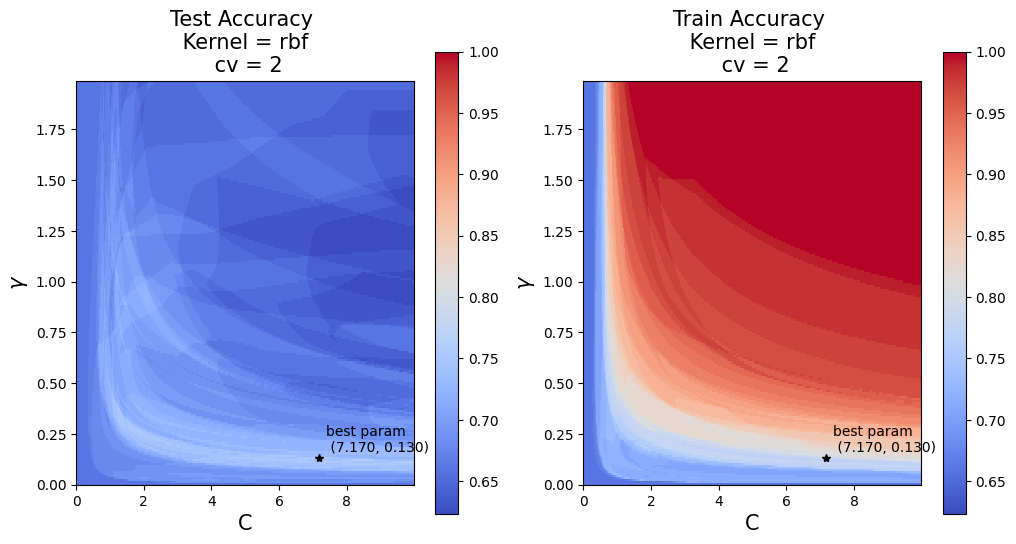

In [20]:
# cv = 2, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv2, best_hyperparams_cv2  = best_param_svm_search(X_train_sc,y_tr,
                                                              2,hyper_params,c,gamma,
                                                              './figs/im_cv2_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv2))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv2))


mcc on training = 0.533
threshold on training = 0.332


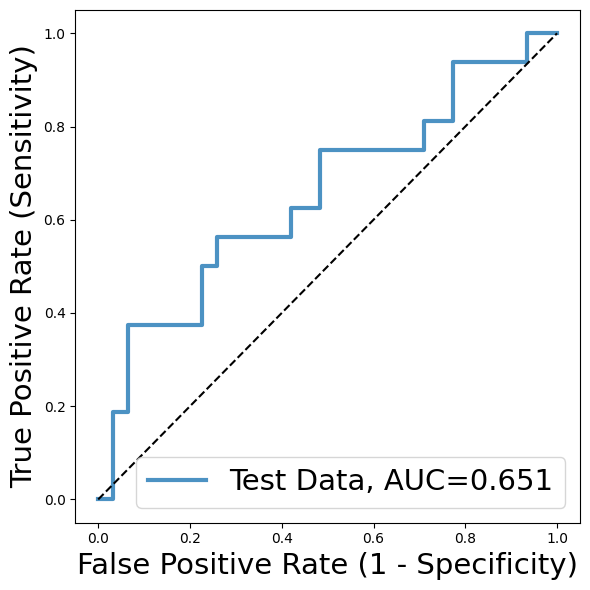

In [21]:
# cv = 2, kl = rbf

# 'MCC'
mcc_Opt_2,thr_Opt_2,y_pred_2,y_test_2,test_probs_2,cm_50_2,cm_Opt_2 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv2,2,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_2))
print("threshold on training = " + str(thr_Opt_2))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_2 = []
threshold = thr_Opt_2

y_pred_opt_2 = [1 if x>=threshold else -1 for x in test_probs_2]


savefig('./figs/AUC_PCa_Ca_2',dpi=1200,quality=100)

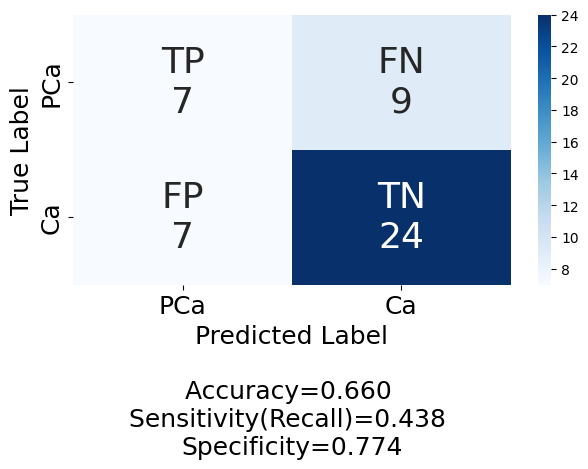

In [22]:
my_cm(cm_Opt_2)
savefig('./figs/PCa_Ca_cm_2',dpi=1200,quality=100)

In [23]:
# CV 3


 ########################################################################## 

Fitting 3 folds for each of 200000 candidates, totalling 600000 fits
Highest test score found by GridSearchCV = 0.7607607607607608
Best hyperparameters found by GridSearchCV = {'C': 1.04, 'gamma': 1.41}


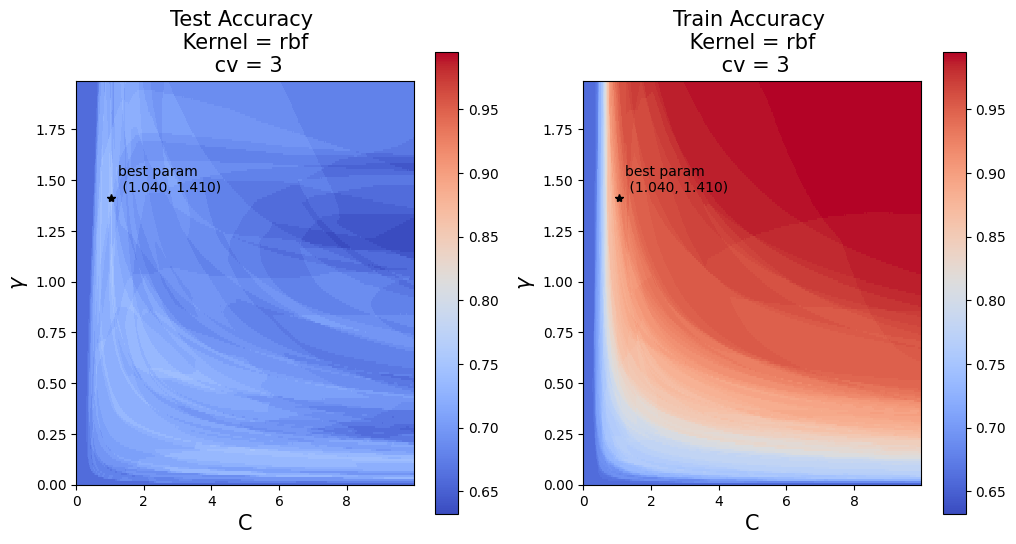

In [24]:
# cv = 3, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv3, best_hyperparams_cv3  = best_param_svm_search(X_train_sc,y_tr,
                                                              3,hyper_params,c,gamma,
                                                              './figs/im_cv3_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv3))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv3))


mcc on training = 0.901
threshold on training = 0.291


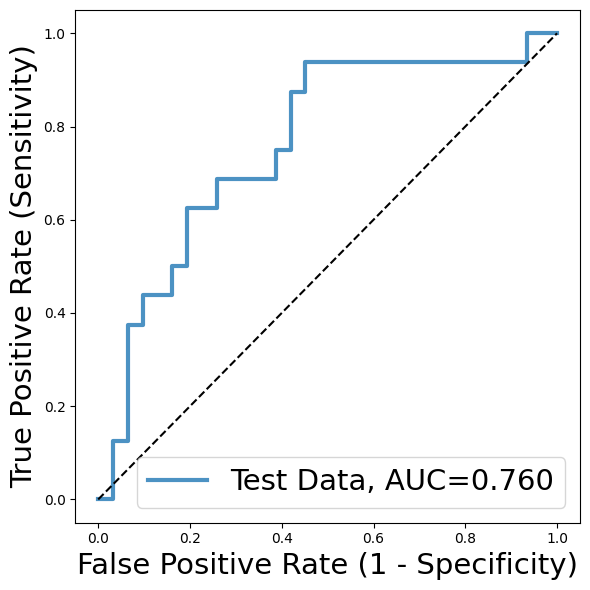

In [25]:
# cv = 3, kl = rbf

# 'MCC'
mcc_Opt_3,thr_Opt_3,y_pred_3,y_test_3,test_probs_3,cm_50_3,cm_Opt_3 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv3,3,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_3))
print("threshold on training = " + str(thr_Opt_3))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_3 = []
threshold = thr_Opt_3

y_pred_opt_3 = [1 if x>=threshold else -1 for x in test_probs_3]


savefig('./figs/AUC_PCa_Ca_3',dpi=1200,quality=100)

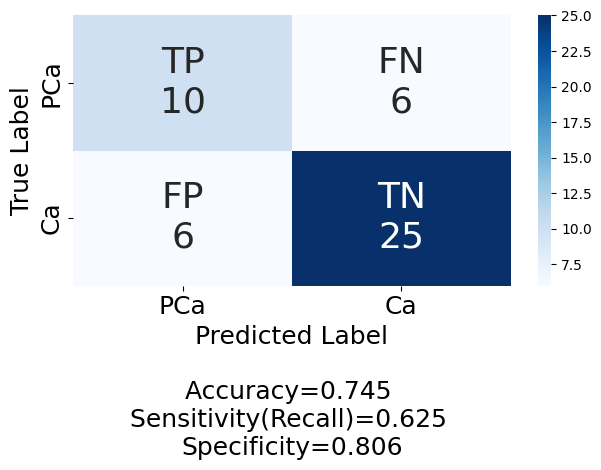

In [26]:
my_cm(cm_Opt_3)
savefig('./figs/PCa_Ca_cm_3',dpi=1200,quality=100)

In [27]:
# CV 4


 ########################################################################## 

Fitting 4 folds for each of 200000 candidates, totalling 800000 fits
Highest test score found by GridSearchCV = 0.7423941798941799
Best hyperparameters found by GridSearchCV = {'C': 0.62, 'gamma': 1.01}


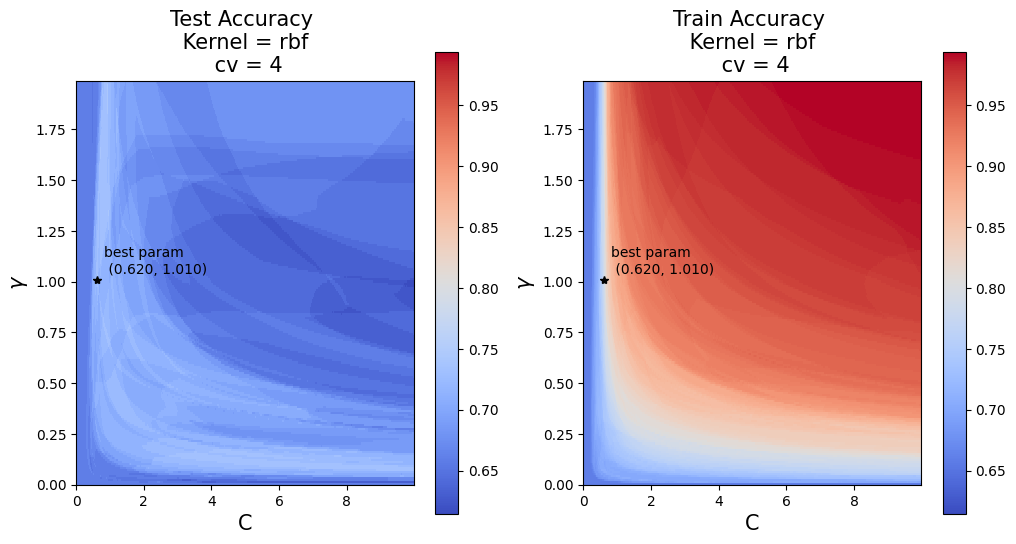

In [28]:
# cv = 4, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv4, best_hyperparams_cv4  = best_param_svm_search(X_train_sc,y_tr,
                                                              4,hyper_params,c,gamma,
                                                              './figs/im_cv4_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv4))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv4))


mcc on training = 0.793
threshold on training = 0.376


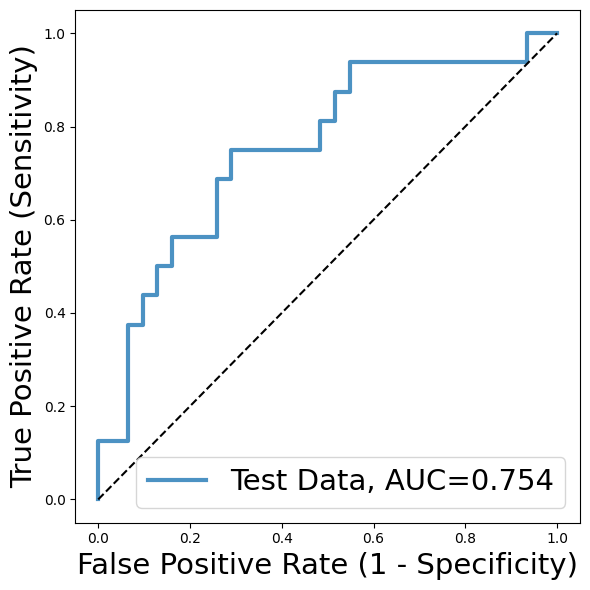

In [29]:
# cv = 4, kl = rbf

# 'MCC'
mcc_Opt_4,thr_Opt_4,y_pred_4,y_test_4,test_probs_4,cm_50_4,cm_Opt_4 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv4,4,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_4))
print("threshold on training = " + str(thr_Opt_4))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_4 = []
threshold = thr_Opt_4

y_pred_opt_4 = [1 if x>=threshold else -1 for x in test_probs_4]


savefig('./figs/AUC_PCa_Ca_4',dpi=1200,quality=100)

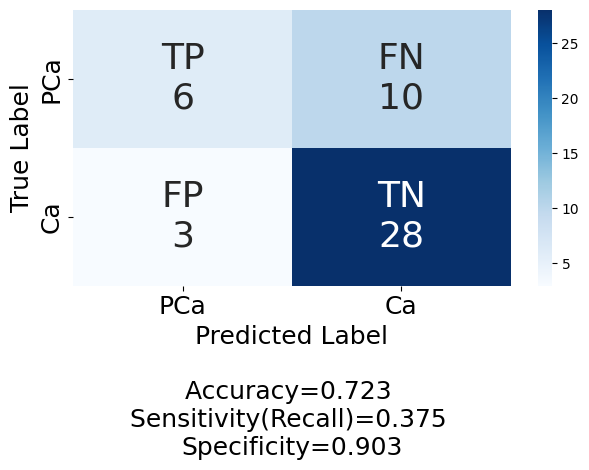

In [30]:
my_cm(cm_Opt_4)
savefig('./figs/PCa_Ca_cm_4',dpi=1200,quality=100)

In [31]:
# CV 5


 ########################################################################## 

Fitting 5 folds for each of 200000 candidates, totalling 1000000 fits
Highest test score found by GridSearchCV = 0.7515151515151516
Best hyperparameters found by GridSearchCV = {'C': 1.47, 'gamma': 0.78}


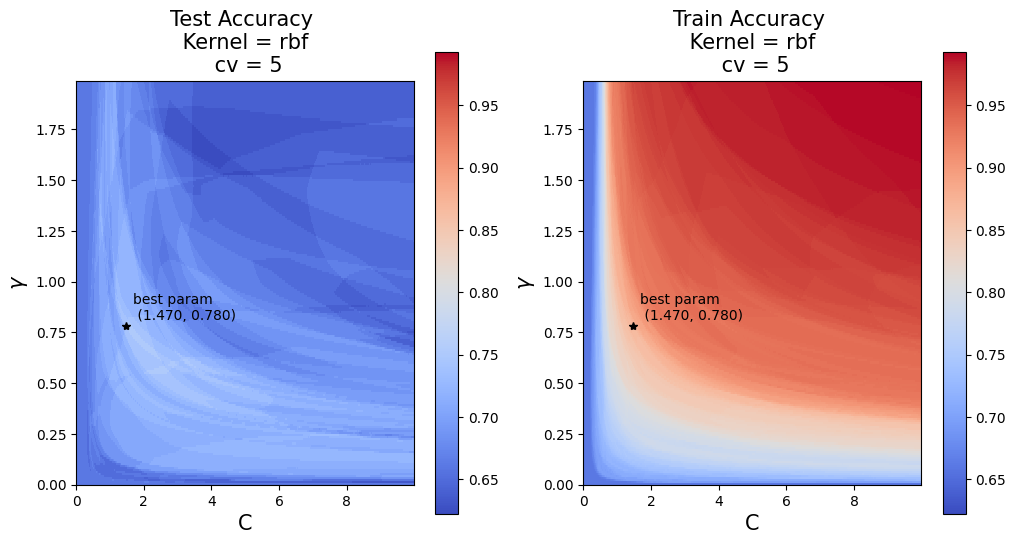

In [32]:
# cv = 5, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv5, best_hyperparams_cv5  = best_param_svm_search(X_train_sc,y_tr,
                                                              5,hyper_params,c,gamma,
                                                              './figs/im_cv5_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv5))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv5))


mcc on training = 0.817
threshold on training = 0.299


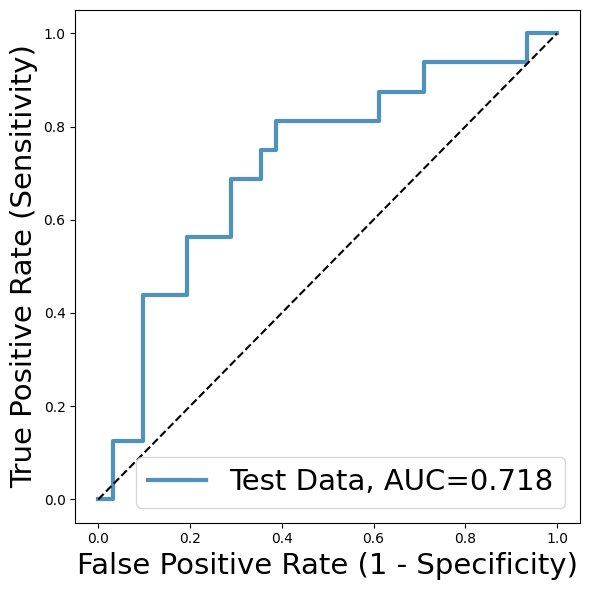

In [33]:
# cv = 5, kl = rbf

# 'MCC'
mcc_Opt_5,thr_Opt_5,y_pred_5,y_test_5,test_probs_5,cm_50_5,cm_Opt_5 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv5,5,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_5))
print("threshold on training = " + str(thr_Opt_5))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_5 = []
threshold = thr_Opt_5

y_pred_opt_5 = [1 if x>=threshold else -1 for x in test_probs_5]


savefig('./figs/AUC_PCa_Ca_5',dpi=1200,quality=100)

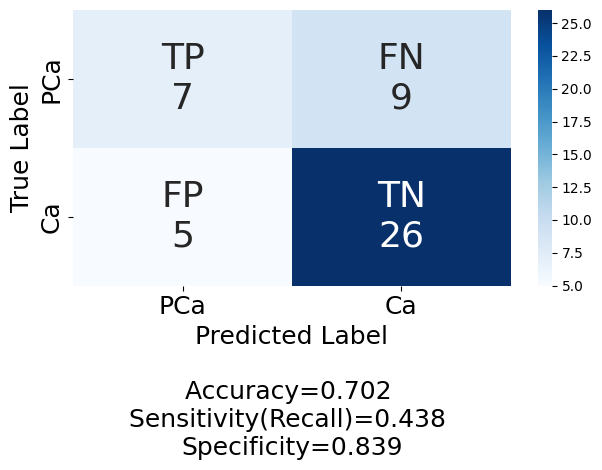

In [34]:
my_cm(cm_Opt_5)
savefig('./figs/PCa_Ca_cm_5',dpi=1200,quality=100)

In [35]:
# CV 6


 ########################################################################## 

Fitting 6 folds for each of 200000 candidates, totalling 1200000 fits
Highest test score found by GridSearchCV = 0.7797270955165693
Best hyperparameters found by GridSearchCV = {'C': 1.1, 'gamma': 0.9400000000000001}


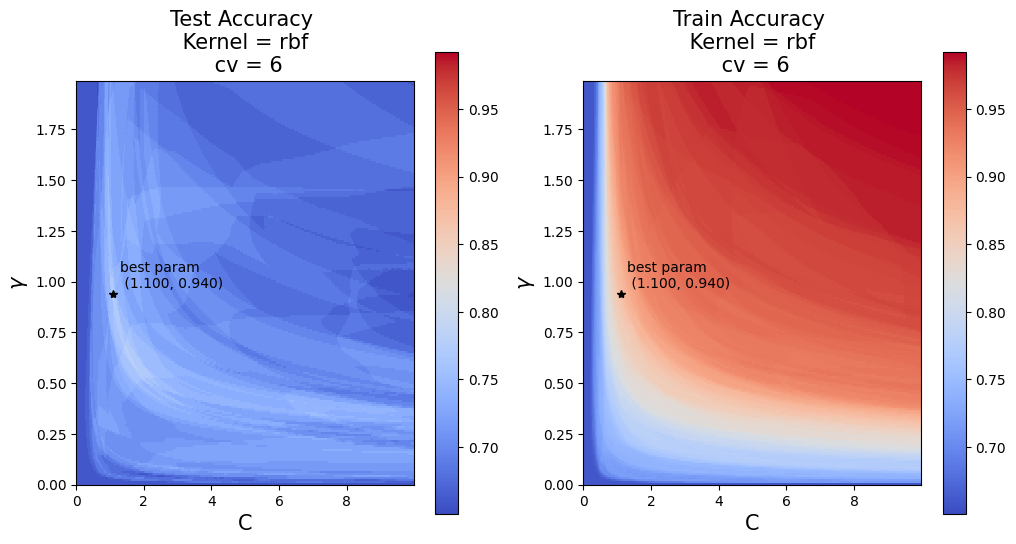

In [36]:
# cv = 6, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv6, best_hyperparams_cv6  = best_param_svm_search(X_train_sc,y_tr,
                                                              6,hyper_params,c,gamma,
                                                              './figs/im_cv6_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv6))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv6))


mcc on training = 0.817
threshold on training = 0.302


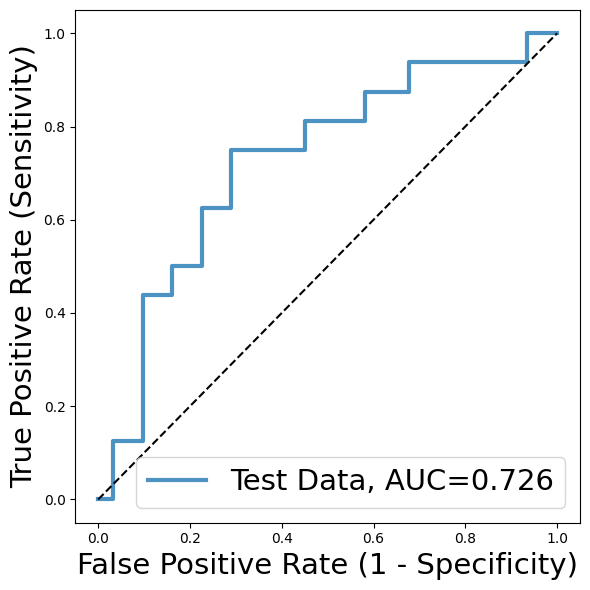

In [37]:
# cv = 6, kl = rbf

# 'MCC'
mcc_Opt_6,thr_Opt_6,y_pred_6,y_test_6,test_probs_6,cm_50_6,cm_Opt_6 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv6,6,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_6))
print("threshold on training = " + str(thr_Opt_6))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_6 = []
threshold = thr_Opt_6

y_pred_opt_6 = [1 if x>=threshold else -1 for x in test_probs_6]


savefig('./figs/AUC_PCa_Ca_6',dpi=1200,quality=100)

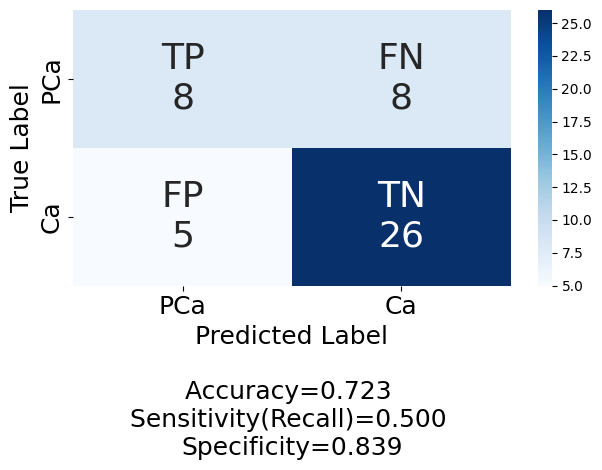

In [38]:
my_cm(cm_Opt_6)
savefig('./figs/PCa_Ca_cm_6',dpi=1200,quality=100)

In [39]:
# CV 7


 ########################################################################## 

Fitting 7 folds for each of 200000 candidates, totalling 1400000 fits
Highest test score found by GridSearchCV = 0.743452380952381
Best hyperparameters found by GridSearchCV = {'C': 1.2, 'gamma': 0.91}


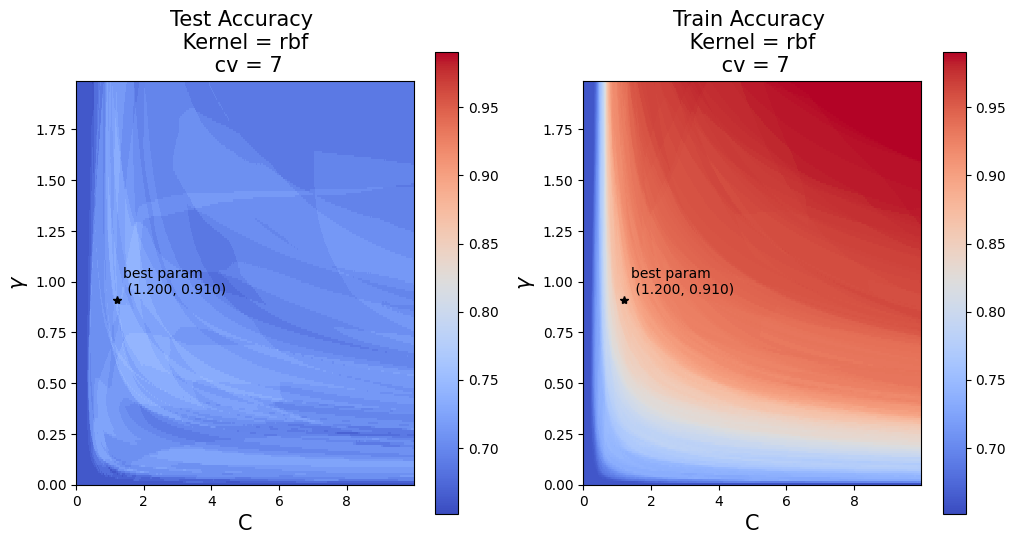

In [40]:
# cv = 7, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv7, best_hyperparams_cv7  = best_param_svm_search(X_train_sc,y_tr,
                                                              7,hyper_params,c,gamma,
                                                              './figs/im_cv7_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv7))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv7))


mcc on training = 0.821
threshold on training = 0.268


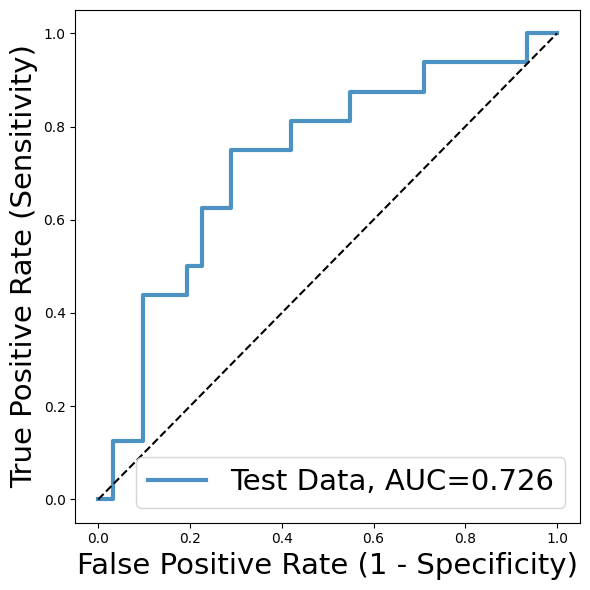

In [41]:
# cv = 7, kl = rbf

# 'MCC'
mcc_Opt_7,thr_Opt_7,y_pred_7,y_test_7,test_probs_7,cm_50_7,cm_Opt_7 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv7,7,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_7))
print("threshold on training = " + str(thr_Opt_7))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_7 = []
threshold = thr_Opt_7

y_pred_opt_7 = [1 if x>=threshold else -1 for x in test_probs_7]


savefig('./figs/AUC_PCa_Ca_7',dpi=1200,quality=100)

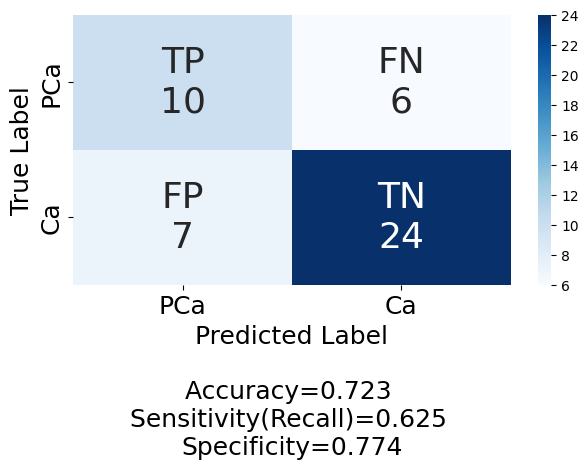

In [42]:
my_cm(cm_Opt_7)
savefig('./figs/PCa_Ca_cm_7',dpi=1200,quality=100)

In [43]:
# CV 8


 ########################################################################## 

Fitting 8 folds for each of 200000 candidates, totalling 1600000 fits
Highest test score found by GridSearchCV = 0.7692307692307692
Best hyperparameters found by GridSearchCV = {'C': 1.1, 'gamma': 1.24}


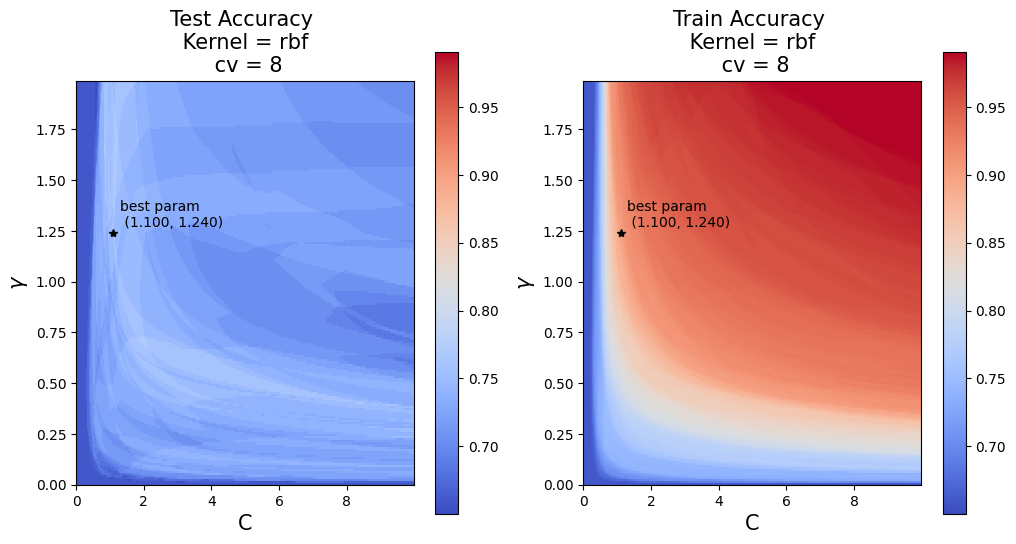

In [44]:
# cv = 8, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv8, best_hyperparams_cv8  = best_param_svm_search(X_train_sc,y_tr,
                                                              8,hyper_params,c,gamma,
                                                              './figs/im_cv8_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv8))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv8))


mcc on training = 0.883
threshold on training = 0.283


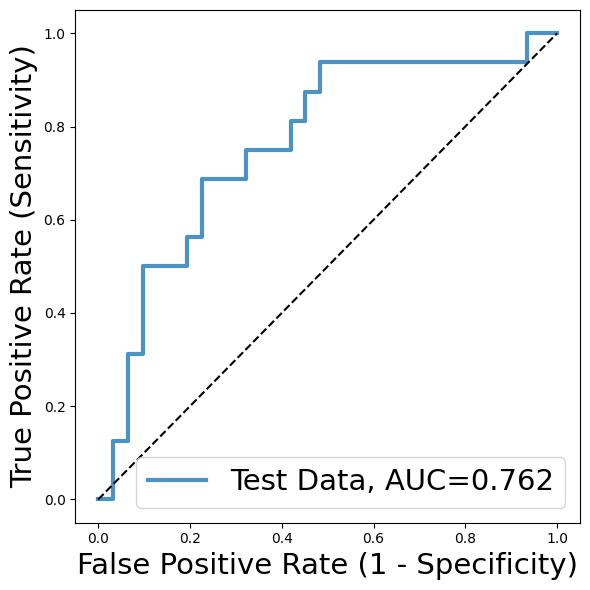

In [45]:
# cv = 8, kl = rbf

# 'MCC'
mcc_Opt_8,thr_Opt_8,y_pred_8,y_test_8,test_probs_8,cm_50_8,cm_Opt_8 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv8,8,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_8))
print("threshold on training = " + str(thr_Opt_8))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_8 = []
threshold = thr_Opt_8

y_pred_opt_8 = [1 if x>=threshold else -1 for x in test_probs_8]


savefig('./figs/AUC_PCa_Ca_8',dpi=1200,quality=100)

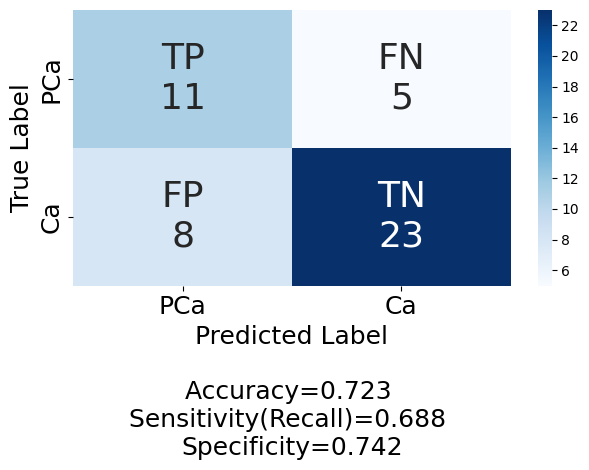

In [46]:
my_cm(cm_Opt_8)
savefig('./figs/PCa_Ca_cm_8',dpi=1200,quality=100)

In [47]:
# CV 9


 ########################################################################## 

Fitting 9 folds for each of 200000 candidates, totalling 1800000 fits
Highest test score found by GridSearchCV = 0.76994301994302
Best hyperparameters found by GridSearchCV = {'C': 4.33, 'gamma': 0.52}


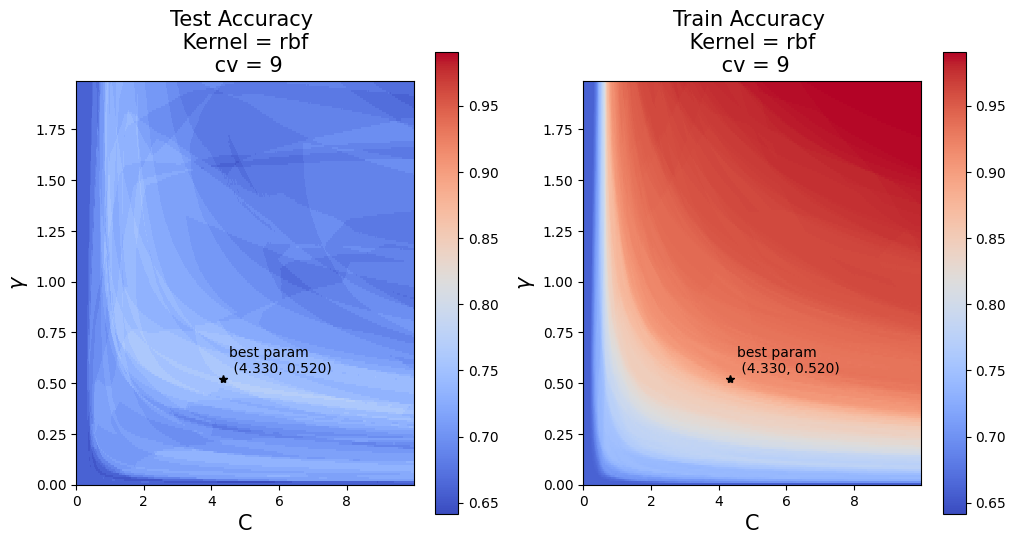

In [48]:
# cv = 9, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv9, best_hyperparams_cv9  = best_param_svm_search(X_train_sc,y_tr,
                                                              9,hyper_params,c,gamma,
                                                              './figs/im_cv9_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv9))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv9))


mcc on training = 0.821
threshold on training = 0.292


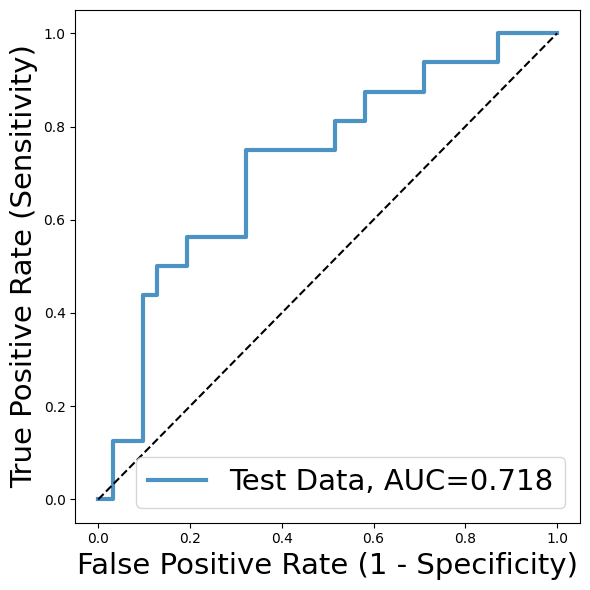

In [49]:
# cv = 9, kl = rbf

# 'MCC'
mcc_Opt_9,thr_Opt_9,y_pred_9,y_test_9,test_probs_9,cm_50_9,cm_Opt_9 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv9,9,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_9))
print("threshold on training = " + str(thr_Opt_9))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_9 = []
threshold = thr_Opt_9

y_pred_opt_9 = [1 if x>=threshold else -1 for x in test_probs_9]


savefig('./figs/AUC_PCa_Ca_9',dpi=1200,quality=100)

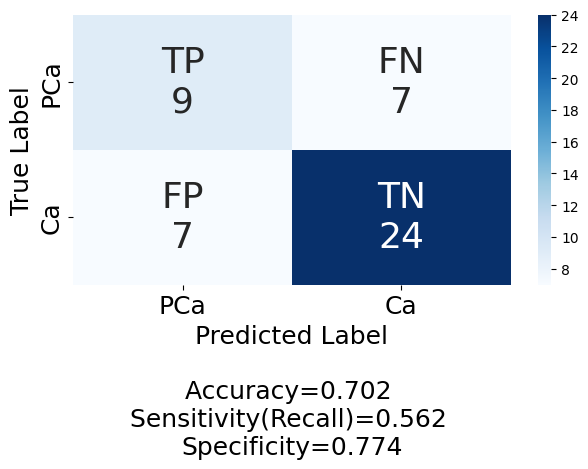

In [50]:
my_cm(cm_Opt_9)
savefig('./figs/PCa_Ca_cm_9',dpi=1200,quality=100)

In [51]:
# CV 10


 ########################################################################## 

Fitting 10 folds for each of 200000 candidates, totalling 2000000 fits
Highest test score found by GridSearchCV = 0.77
Best hyperparameters found by GridSearchCV = {'C': 1.62, 'gamma': 0.72}


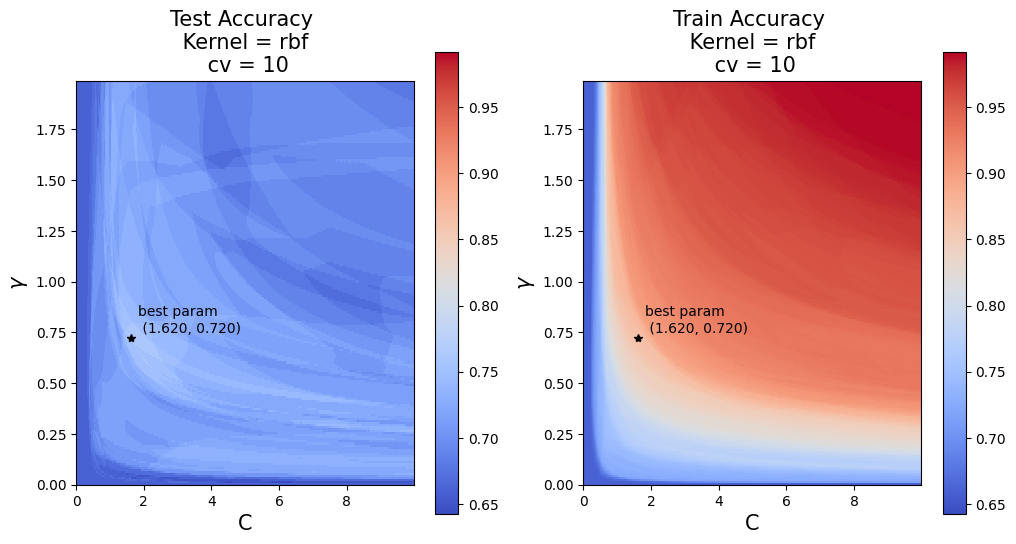

In [52]:
# cv = 10, kl = rbf, plot_surface and im_show

print('\n ########################################################################## \n')

best_score_cv10, best_hyperparams_cv10  = best_param_svm_search(X_train_sc,y_tr,
                                                              10,hyper_params,c,gamma,
                                                              './figs/im_cv10_pca_ca',
                                                              kl ="rbf",rnd_st=1234)
# cv is optimal if |best_test_score - best_train_score| is minimum

print("Highest test score found by GridSearchCV = " + str(best_score_cv10))
print("Best hyperparameters found by GridSearchCV = " + str(best_hyperparams_cv10))


mcc on training = 0.803
threshold on training = 0.284


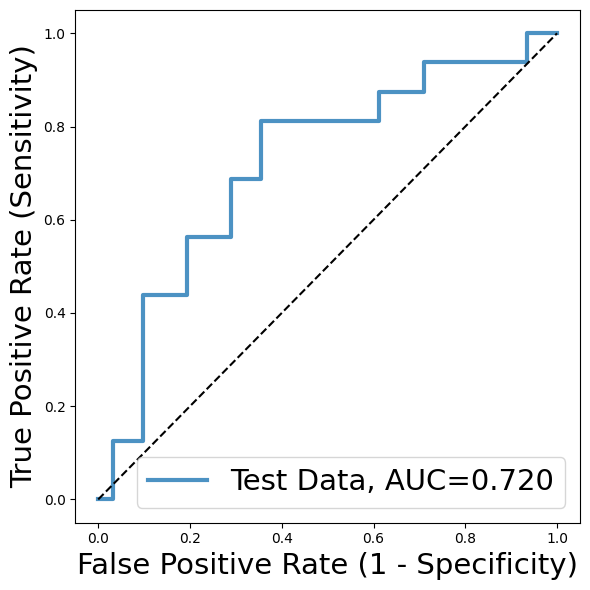

In [53]:
# cv = 10, kl = rbf

# 'MCC'
mcc_Opt_10,thr_Opt_10,y_pred_10,y_test_10,test_probs_10,cm_50_10,cm_Opt_10 = model_svm_predict(X_train_sc,y_tr,
                                                                    X_test_sc,y_tt,
                                                                    best_hyperparams_cv10,10,
                                                                    K_R_M = 'MCC',kl ="rbf")
print("mcc on training = " + str(mcc_Opt_10))
print("threshold on training = " + str(thr_Opt_10))

# confidence intervals for accuracy,recall,precision,specificity
y_pred_opt_10 = []
threshold = thr_Opt_10

y_pred_opt_10 = [1 if x>=threshold else -1 for x in test_probs_10]


savefig('./figs/AUC_PCa_Ca_10',dpi=1200,quality=100)

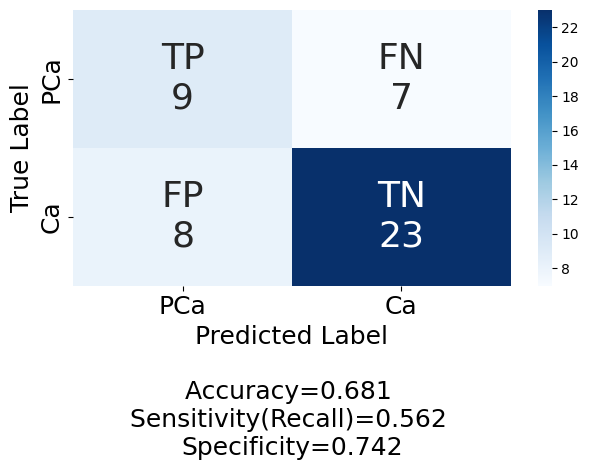

In [54]:
my_cm(cm_Opt_10)
savefig('./figs/PCa_Ca_cm_10',dpi=1200,quality=100)